# Goal -> Compute RFM  values per customer, assign customer segments, and visualise the results for  targated  marketing 

# Dataset Load and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

SEGMENT_COLORS = {
    'Champions'           : '#2ECC71',
    'Loyal Customers'     : '#27AE60',
    'Potential Loyalists' : '#3498DB',
    'Needs Attention'     : '#F39C12',
    "Can't Lose Them"     : '#E67E22',
    'At Risk'             : '#E74C3C',
    'Hibernating'         : '#95A5A6',
}

dt = pd.read_csv('./data/01_preprocessed.csv', parse_dates=['order_date'])
print(f"Loaded: {dt.shape[0]:,} rows × {dt.shape[1]} columns")
print(f"Unique customers: {dt['customer_id'].nunique():,}")

Loaded: 34,500 rows × 24 columns
Unique customers: 7,903


## Compute Recency, Frequency, Monetary

| Metric | Definition | Column used |
|---|---|---|
| **Recency** | Days since customer's last purchase | `order_date` |
| **Frequency** | Number of unique orders placed | `order_id` |
| **Monetary** | Total spend across all orders | `total_amount` |

Snapshot date = last transaction date + 1 day (standard convention).


In [2]:
snapshot_date = dt['order_date'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = dt.groupby('customer_id').agg(
    Recency   = ('order_date',    lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id',      'nunique'),
    Monetary  = ('total_amount',  'sum')
).reset_index()

print(f"RFM table shape: {rfm.shape}")
print()
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

Snapshot date: 2025-09-12
RFM table shape: (7903, 4)



,Recency,Frequency,Monetary
count,7903.00,7903.00,7903.00
mean,159.01,4.37,742.16
std,147.06,2.05,827.18
min,1.00,1.00,1.24
25%,47.00,3.00,215.88
50%,115.00,4.00,494.45
75%,226.00,6.00,972.46
max,729.00,13.00,13885.10


## Score R, F, M (1 – 5)

Each dimension is split into quintiles using **rank-based qcut** (avoids failures on duplicate values).

- **Recency**: lower days → higher score (label order is reversed `[5,4,3,2,1]`)
- **Frequency**: more orders → higher score
- **Monetary**: more spend → higher score


In [3]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),   q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

In [4]:
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
rfm['RFM_Label'] = (rfm['R_Score'].astype(str) + '-' +
                    rfm['F_Score'].astype(str) + '-' +
                    rfm['M_Score'].astype(str))

In [5]:
print("Score distribution (should be ~20% each):")
for col in ['R_Score', 'F_Score', 'M_Score']:
    dist = rfm[col].value_counts(normalize=True).sort_index().mul(100).round(1)
    print(f"  {col}: {dict(dist)}")

Score distribution (should be ~20% each):
  R_Score: {1: np.float64(20.0), 2: np.float64(20.0), 3: np.float64(20.0), 4: np.float64(20.0), 5: np.float64(20.0)}
  F_Score: {1: np.float64(20.0), 2: np.float64(20.0), 3: np.float64(20.0), 4: np.float64(20.0), 5: np.float64(20.0)}
  M_Score: {1: np.float64(20.0), 2: np.float64(20.0), 3: np.float64(20.0), 4: np.float64(20.0), 5: np.float64(20.0)}


# Customer Segments

Segments are defined primarily by **Recency** and **Frequency** scores. Monetary is captured
indirectly through the composite score and is used only for heatmap analysis.

| Segment | R | F | Description |
|---|---|---|---|
| **Champions** | ≥ 4 | ≥ 4 | Bought recently, often, and spend the most |
| **Loyal Customers** | ≥ 3 | ≥ 3 | Regular buyers, engaged with the brand |
| **Potential Loyalists** | ≥ 4 | < 3 | New/recent shoppers showing promise |
| **Needs Attention** | 3 | < 3 | Decent history but engagement is slipping |
| **Can't Lose Them** | ≤ 2 | ≥ 4 | Were very active, now going cold — urgent |
| **At Risk** | ≤ 2 | ≥ 2 | Bought a few times, becoming inactive |
| **Hibernating** | ≤ 2 | < 2 | Largely inactive, low overall engagement |


In [6]:
def assign_segment(row):
    r, f = row['R_Score'], row['F_Score']
    if   r >= 4 and f >= 4: return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal Customers'
    elif r >= 4 and f  < 3: return 'Potential Loyalists'
    elif r <= 2 and f >= 4: return "Can't Lose Them"
    elif r <= 2 and f >= 2: return 'At Risk'
    elif r == 3 and f  < 3: return 'Needs Attention'
    else:                   return 'Hibernating'




In [7]:
rfm['Segment'] = rfm.apply(assign_segment, axis=1)

seg_dist = rfm['Segment'].value_counts()
print("=== SEGMENT DISTRIBUTION ===")
for seg, count in seg_dist.items():
    pct = count / len(rfm) * 100
    print(f"  {seg:<25} {count:>5,}  ({pct:.1f}%)")
print(f"  {'TOTAL':<25} {len(rfm):>5,}")

=== SEGMENT DISTRIBUTION ===
  Loyal Customers           1,737  (22.0%)
  Champions                 1,697  (21.5%)
  At Risk                   1,355  (17.1%)
  Hibernating               1,053  (13.3%)
  Potential Loyalists         788  (10.0%)
  Can't Lose Them             753  (9.5%)
  Needs Attention             520  (6.6%)
  TOTAL                     7,903


# Visualisations

## 1. Raw Distribution

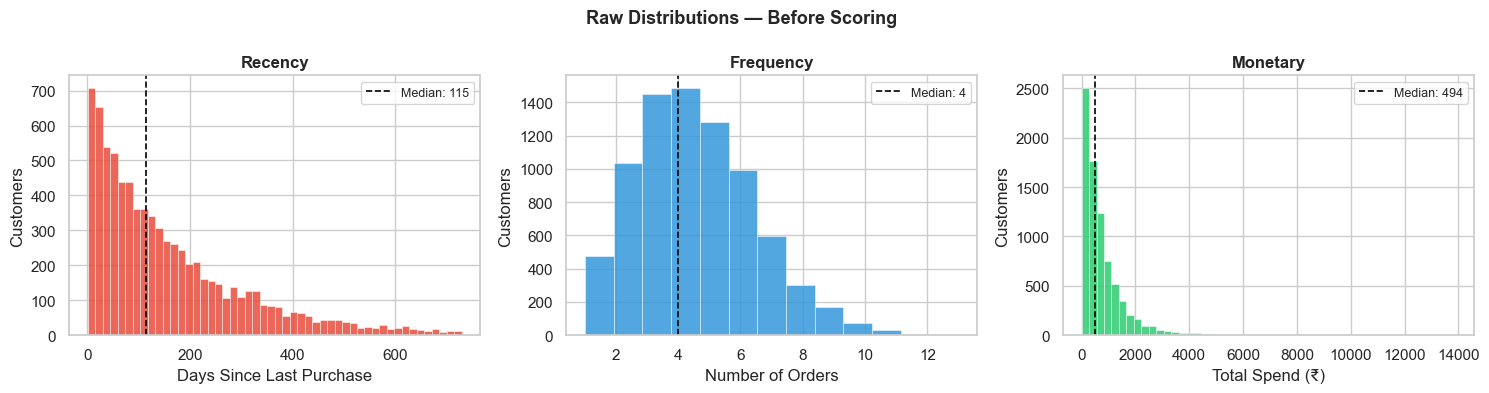

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Raw Distributions — Before Scoring', fontsize=13, fontweight='bold')

plot_cfg = [
    ('Recency',   'Days Since Last Purchase',  '#E74C3C', 50),
    ('Frequency', 'Number of Orders',          '#3498DB', 13),
    ('Monetary',  'Total Spend (₹)',            '#2ECC71', 50),
]

for ax, (col, xlabel, color, bins) in zip(axes, plot_cfg):
    ax.hist(rfm[col], bins=bins, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {rfm[col].median():.0f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Customers')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 2. Score Distribution

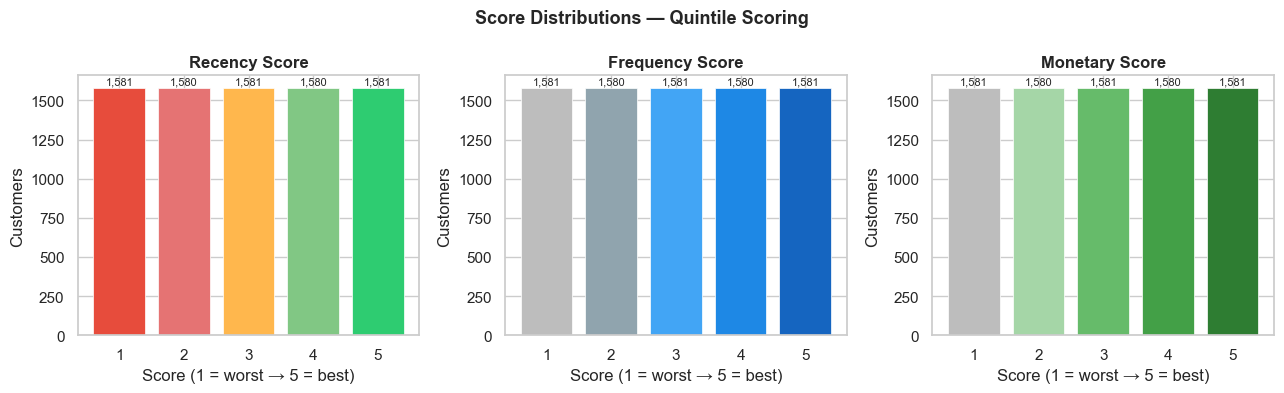

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Score Distributions — Quintile Scoring', fontsize=13, fontweight='bold')

score_cfg = [
    ('R_Score', 'Recency Score',   ['#E74C3C','#E57373','#FFB74D','#81C784','#2ECC71']),
    ('F_Score', 'Frequency Score', ['#BDBDBD','#90A4AE','#42A5F5','#1E88E5','#1565C0']),
    ('M_Score', 'Monetary Score',  ['#BDBDBD','#A5D6A7','#66BB6A','#43A047','#2E7D32']),
]

for ax, (col, title, colors) in zip(axes, score_cfg):
    counts = rfm[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Score (1 = worst → 5 = best)')
    ax.set_ylabel('Customers')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Segment Distribution

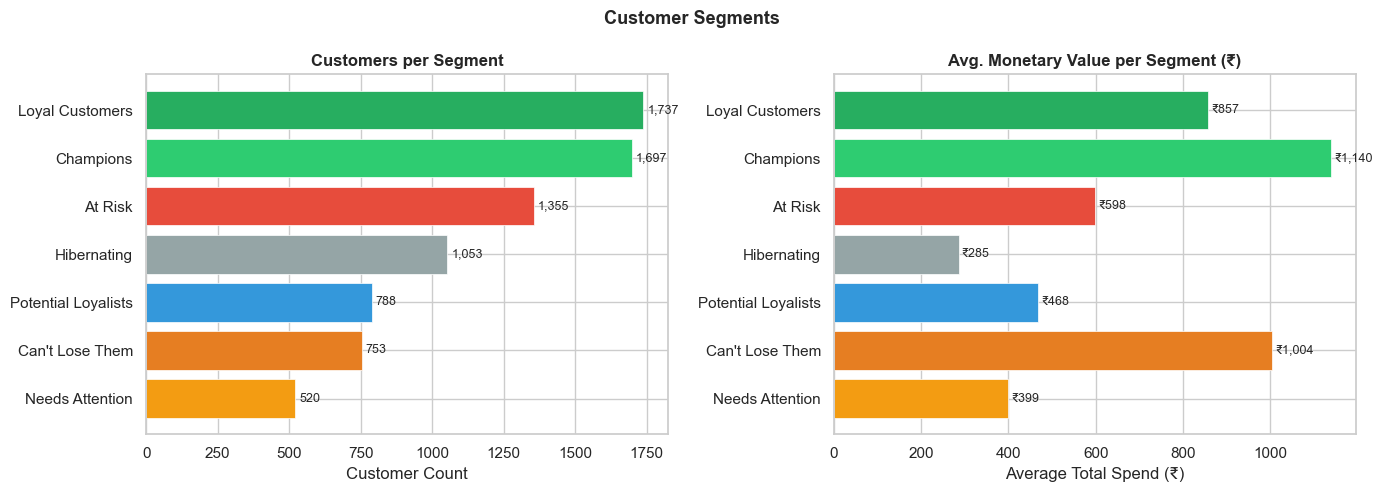

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segments', fontsize=13, fontweight='bold')

seg_counts = rfm['Segment'].value_counts()
seg_monetary = rfm.groupby('Segment')['Monetary'].mean().reindex(seg_counts.index)

# Left: customer count (horizontal bar)
colors_ordered = [SEGMENT_COLORS[s] for s in seg_counts.index]
bars = axes[0].barh(seg_counts.index, seg_counts.values,
                    color=colors_ordered, edgecolor='white', linewidth=0.5)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Customer Count')
for bar in bars:
    w = bar.get_width()
    axes[0].text(w + 15, bar.get_y() + bar.get_height()/2,
                 f'{int(w):,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Right: average spend per segment
colors_monetary = [SEGMENT_COLORS[s] for s in seg_monetary.index]
bars2 = axes[1].barh(seg_monetary.index, seg_monetary.values,
                     color=colors_monetary, edgecolor='white', linewidth=0.5)
axes[1].set_title('Avg. Monetary Value per Segment (₹)', fontweight='bold')
axes[1].set_xlabel('Average Total Spend (₹)')
for bar in bars2:
    w = bar.get_width()
    axes[1].text(w + 8, bar.get_y() + bar.get_height()/2,
                 f'₹{w:,.0f}', va='center', fontsize=9)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 4. RFM Heatmap — Average Spend by R & F Score

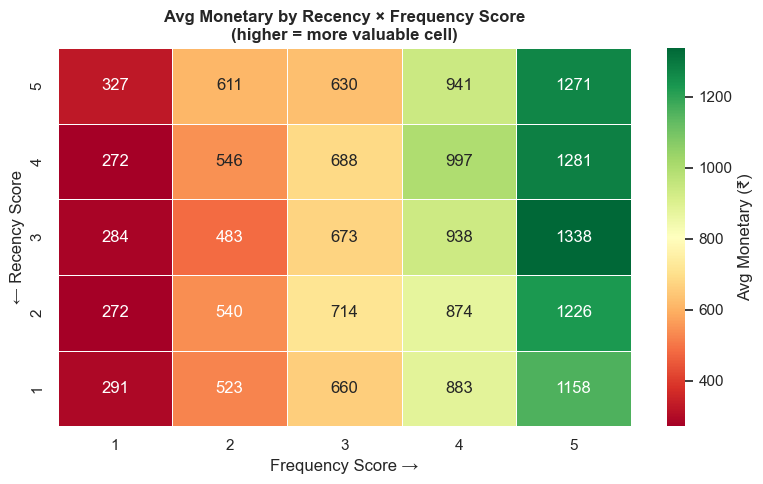

In [11]:
pivot = rfm.pivot_table(
    index='R_Score', columns='F_Score',
    values='Monetary', aggfunc='mean'
).round(0)

# Flip so score=5 is at top-left (most desirable)
pivot = pivot.iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='RdYlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Avg Monetary (₹)'},
    ax=ax
)
ax.set_title('Avg Monetary by Recency × Frequency Score\n(higher = more valuable cell)', fontweight='bold')
ax.set_xlabel('Frequency Score →')
ax.set_ylabel('← Recency Score')

plt.tight_layout()
plt.show()

## 5. Scatter — Recency vs Monetary, coloured by Segment

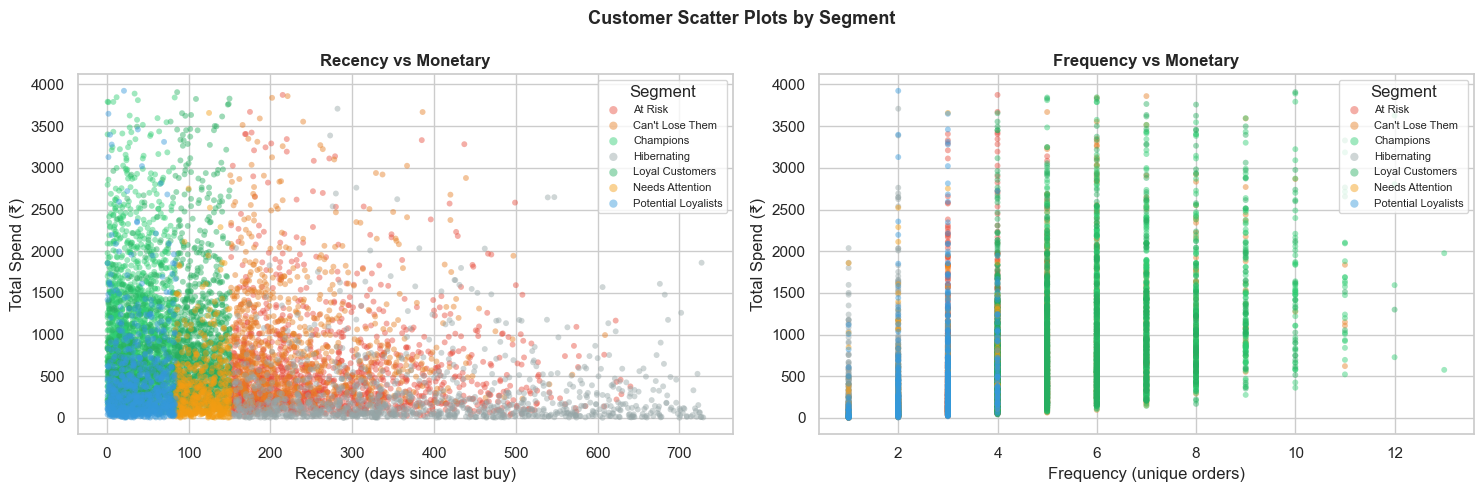

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Customer Scatter Plots by Segment', fontsize=13, fontweight='bold')

# Cap Monetary at 99th pct for better visibility
m_cap = rfm['Monetary'].quantile(0.99)
plot_df = rfm[rfm['Monetary'] <= m_cap].copy()

# Left: Recency vs Monetary
for seg, grp in plot_df.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Monetary'],
                    label=seg, color=SEGMENT_COLORS[seg],
                    alpha=0.45, s=18, edgecolors='none')
axes[0].set_title('Recency vs Monetary', fontweight='bold')
axes[0].set_xlabel('Recency (days since last buy)')
axes[0].set_ylabel('Total Spend (₹)')
axes[0].legend(fontsize=8, title='Segment', markerscale=1.4)

# Right: Frequency vs Monetary
for seg, grp in plot_df.groupby('Segment'):
    axes[1].scatter(grp['Frequency'], grp['Monetary'],
                    label=seg, color=SEGMENT_COLORS[seg],
                    alpha=0.45, s=18, edgecolors='none')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].set_xlabel('Frequency (unique orders)')
axes[1].set_ylabel('Total Spend (₹)')
axes[1].legend(fontsize=8, title='Segment', markerscale=1.4)

plt.tight_layout()
plt.show()

#  Segment Summary & Marketing Actions

Key KPIs per segment + recommended campaign strategy.


In [13]:
summary = rfm.groupby('Segment').agg(
    Customers   = ('customer_id', 'count'),
    Avg_Recency = ('Recency',     'mean'),
    Avg_Freq    = ('Frequency',   'mean'),
    Avg_Monetary= ('Monetary',    'mean'),
    Total_Rev   = ('Monetary',    'sum'),
).round(1)

summary['Pct_Customers'] = (summary['Customers'] / len(rfm) * 100).round(1)
summary['Pct_Revenue']   = (summary['Total_Rev']  / rfm['Monetary'].sum() * 100).round(1)

# Sort by Avg_Monetary descending
summary = summary.sort_values('Avg_Monetary', ascending=False)

print("=== SEGMENT KPI SUMMARY ===\n")
print(summary[['Customers','Pct_Customers','Avg_Recency',
               'Avg_Freq','Avg_Monetary','Pct_Revenue']].to_string())

=== SEGMENT KPI SUMMARY ===

                     Customers  Pct_Customers  Avg_Recency  Avg_Freq  Avg_Monetary  Pct_Revenue
Segment                                                                                        
Champions                 1697          21.50        36.20      6.60       1139.50        33.00
Can't Lose Them            753           9.50       238.10      6.00       1003.60        12.90
Loyal Customers           1737          22.00        85.60      5.10        857.50        25.40
At Risk                   1355          17.10       274.90      3.50        597.60        13.80
Potential Loyalists        788          10.00        40.30      2.70        467.80         6.30
Needs Attention            520           6.60       117.60      2.60        398.80         3.50
Hibernating               1053          13.30       381.70      1.70        285.40         5.10


In [14]:
marketing_actions = {
    'Champions'           : '🏆 Reward with VIP perks, early product access, referral incentives',
    'Loyal Customers'     : '💚 Offer loyalty programmes, upsell premium categories',
    'Potential Loyalists' : '🔵 Onboarding emails, recommend top-selling products',
    'Needs Attention'     : '🟡 Limited-time offers, resurface best-selling categories',
    "Can't Lose Them"     : '🔶 Urgent win-back — heavy discounts, personal outreach',
    'At Risk'             : '🔴 Reactivation emails, personalised discount codes',
    'Hibernating'         : '⚪ Low-cost newsletter, flash sales to re-spark interest',
}

print("=== MARKETING ACTION PLAN ===\n")
for seg in summary.index:
    cust = summary.loc[seg, 'Customers']
    pct  = summary.loc[seg, 'Pct_Revenue']
    print(f"{seg:<25} | {cust:>5,} customers | {pct:.1f}% of revenue")
    print(f"  ↳ {marketing_actions[seg]}\n")

=== MARKETING ACTION PLAN ===

Champions                 | 1,697 customers | 33.0% of revenue
  ↳ 🏆 Reward with VIP perks, early product access, referral incentives

Can't Lose Them           |   753 customers | 12.9% of revenue
  ↳ 🔶 Urgent win-back — heavy discounts, personal outreach

Loyal Customers           | 1,737 customers | 25.4% of revenue
  ↳ 💚 Offer loyalty programmes, upsell premium categories

At Risk                   | 1,355 customers | 13.8% of revenue
  ↳ 🔴 Reactivation emails, personalised discount codes

Potential Loyalists       |   788 customers | 6.3% of revenue
  ↳ 🔵 Onboarding emails, recommend top-selling products

Needs Attention           |   520 customers | 3.5% of revenue
  ↳ 🟡 Limited-time offers, resurface best-selling categories

Hibernating               | 1,053 customers | 5.1% of revenue
  ↳ ⚪ Low-cost newsletter, flash sales to re-spark interest



In [15]:
import os
os.makedirs('./data', exist_ok=True)
rfm.to_csv('./data/02_rfm.csv', index=False)
summary.reset_index().to_csv('./data/02_segment_summary.csv', index=False)

